<a href="https://colab.research.google.com/github/aditya-r21/Deep-Learning/blob/main/Tabular_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/asifxzaman/e-commerce-behavior-dataset8000-users")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: AdiRaj21
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/asifxzaman/e-commerce-behavior-dataset8000-users


100%|██████████| 148k/148k [00:00<00:00, 90.8MB/s]

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
data_df = pd.read_csv('/content/e-commerce-behavior-dataset8000-users/ecommerce_user_behavior_8000.csv')
data_df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [ ]:
data_df.dropna(inplace = True)
data_df.drop(["user_id"], axis = 1, inplace = True)
data_df['gender'] = data_df['gender'].map({'Male': 1, 'Female': 0})
data_df['device_type'] = data_df['device_type'].map({'Desktop': 2, 'Mobile': 1, 'Tablet': 0})

print("Output possibilities: ", data_df["purchase"].unique())
print("Data Shape (rows, cols): ", data_df.shape)
data_df.head()

Output possibilities:  [1. 0.]
Data Shape (rows, cols):  (6019, 13)


,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
1,46.0,1,1,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
4,38.0,0,1,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,56.0,0,2,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,36.0,1,1,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,40.0,0,1,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0


In [ ]:
original_df = data_df.copy()

for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max()
data_df.head()

,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
1,0.779661,1.0,0.5,0.521000,0.473684,0.285714,0.666667,1.0,1.0,1.0,0.428380,0.867560,1.0
4,0.644068,0.0,0.5,0.878333,0.473684,0.857143,0.444444,1.0,0.0,0.0,0.405587,0.553666,1.0
5,0.949153,0.0,1.0,0.886667,0.052632,0.857143,0.777778,1.0,1.0,0.0,0.634637,0.139042,1.0
6,0.610169,1.0,0.5,0.253333,0.578947,0.785714,0.666667,1.0,1.0,1.0,0.100782,0.131239,1.0
7,0.677966,0.0,0.5,0.899333,0.368421,0.357143,0.222222,1.0,0.0,0.0,0.745028,0.126138,1.0


In [ ]:
X = np.array(data_df.iloc[:,:-1])
Y = np.array(data_df.iloc[:, -1])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5)

print("Training set is: ", X_train.shape[0], " rows which is ", round(X_train.shape[0]/data_df.shape[0],4)*100, "%")
print("Validation set is: ",X_val.shape[0], " rows which is ", round(X_val.shape[0]/data_df.shape[0],4)*100, "%")
print("Testing set is: ",X_test.shape[0], " rows which is ", round(X_test.shape[0]/data_df.shape[0],4)*100, "%")

Training set is:  4213  rows which is  70.0 %
Validation set is:  903  rows which is  15.0 %
Testing set is:  903  rows which is  15.0 %


In [ ]:
class dataset(Dataset):
  def __init__(self, X, Y):
    self.X = torch.tensor(X, dtype = torch.float32).to(device)
    self.Y = torch.tensor(Y, dtype = torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]

training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [ ]:
BATCH_SIZE = 32
EPOCHS = 10
HIDDEN_NEURONS = 10
LR = 1e-3

In [ ]:
train_dataloader = DataLoader(training_data, batch_size = BATCH_SIZE, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = BATCH_SIZE, shuffle = True)
testing_dataloader = DataLoader(testing_data, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
class MyModel(nn.Module):
  def __init__(self):
    super(MyModel, self).__init__()
    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.input_layer(x)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x

In [ ]:
model = MyModel().to(device)
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             130
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 141
Trainable params: 141
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [ ]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for data in train_dataloader:
    inputs, labels = data
    prediction = model(inputs).squeeze(1)
    batch_loss = criterion(prediction, labels)
    total_loss_train += batch_loss.item()
    acc = ((prediction).round() == labels).sum().item()
    total_acc_train += acc
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels = data
      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels)
      total_loss_val += batch_loss.item()
      acc = ((prediction).round() == labels).sum().item()
      total_acc_val += acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_val_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
  total_acc_val_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

  print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')


Epoch no. 1 Train Loss: 0.0379 Train Accuracy: 99.7152 Validation Loss: 0.0028 Validation Accuracy: 99.7785
Epoch no. 2 Train Loss: 0.0070 Train Accuracy: 99.7864 Validation Loss: 0.0008 Validation Accuracy: 99.7785
Epoch no. 3 Train Loss: 0.0030 Train Accuracy: 99.7864 Validation Loss: 0.0005 Validation Accuracy: 99.7785
Epoch no. 4 Train Loss: 0.0021 Train Accuracy: 99.7864 Validation Loss: 0.0004 Validation Accuracy: 99.7785
Epoch no. 5 Train Loss: 0.0019 Train Accuracy: 99.7864 Validation Loss: 0.0004 Validation Accuracy: 99.7785
Epoch no. 6 Train Loss: 0.0017 Train Accuracy: 99.7864 Validation Loss: 0.0003 Validation Accuracy: 99.7785
Epoch no. 7 Train Loss: 0.0017 Train Accuracy: 99.7864 Validation Loss: 0.0003 Validation Accuracy: 99.7785
Epoch no. 8 Train Loss: 0.0016 Train Accuracy: 99.7864 Validation Loss: 0.0003 Validation Accuracy: 99.7785
Epoch no. 9 Train Loss: 0.0016 Train Accuracy: 99.7864 Validation Loss: 0.0003 Validation Accuracy: 99.7785
Epoch no. 10 Train Loss: 0.0

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs, labels = data
    prediction = model(inputs).squeeze(1)
    batch_loss_test = criterion((prediction), labels)
    total_loss_test += batch_loss_test.item()
    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100, 2)}%")

Accuracy Score is: 100.0%


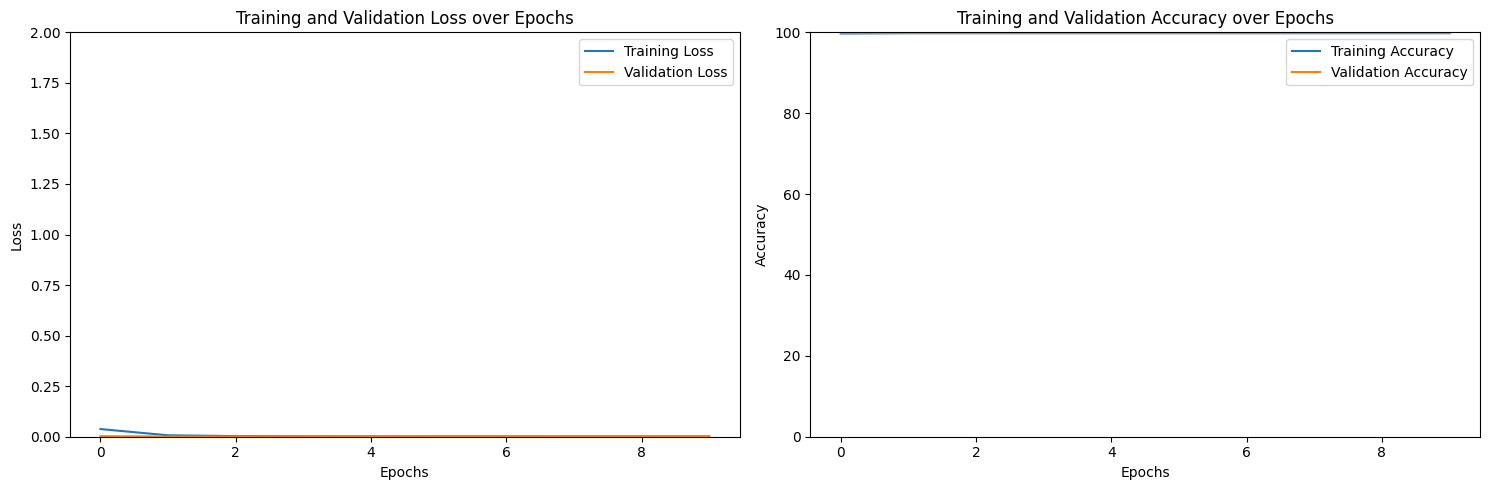

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_val_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

In [ ]:
age = float(input("Age: "))/original_df['age'].abs().max()
gender = str(input("Gender: "))
if gender == 'Male':
  gender = 1
else:
  gender = 0
gender = float(gender)/original_df['gender'].abs().max()
device_type = str(input("Device Type: "))
if device_type == 'Desktop':
  device_type = 2
elif device_type == 'Mobile':
  device_type = 1
else:
  device_type = 0
device_type = float(device_type)/original_df['device_type'].abs().max()
time_on_site = float(input("Time on Site: "))/original_df['time_on_site'].abs().max()
pages_viewed = float(input("Pages Viewed: "))/original_df['pages_viewed'].abs().max()
previous_purchases = float(input("Previous Purchases: "))/original_df['previous_purchases'].abs().max()
cart_items = float(input("Cart Items: "))/original_df['cart_items'].abs().max()
discount_seen = float(input("Discount Seen: "))/original_df['discount_seen'].abs().max()
ad_clicked = float(input("Ads Clicked: "))/original_df['ad_clicked'].abs().max()
returning_user = float(input("Returning User: "))/original_df['returning_user'].abs().max()
avg_session_time = float(input("Average Session Time: "))/original_df['avg_session_time'].abs().max()
bounce_rate = float(input("Bounce Rate: "))/original_df['bounce_rate'].abs().max()

my_inputs = [age, gender, device_type, time_on_site, pages_viewed, previous_purchases, cart_items, discount_seen, ad_clicked, returning_user, avg_session_time, bounce_rate]

model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Will Purchase?: ", round(prediction.item()))

Age: 19
Gender: Male
Device Type: Mobile
Time on Site: 28
Pages Viewed: 11
Previous Purchases: 1
Cart Items: 3
Discount Seen: 0
Ads Clicked: 2
Returning User: 0
Average Session Time: 17
Bounce Rate: 28
tensor([0.9982], device='cuda:0', grad_fn=<SigmoidBackward0>)
Class is:  1
